In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Import data (Make sure to parse dates. Consider setting index column to 'date'.)
df = pd.read_csv('fcc-forum-pageviews.csv', parse_dates=True, index_col='date')

# Clean data
df = df[(df.value > df.value.quantile(0.025)) & (df.value < df.value.quantile(0.975))]


def draw_line_plot():
    # Draw line plot
    # fig = df.plot.line(figsize=(15,5), legend=False, color='red')
    # plt.title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
    # plt.xlabel('Date')
    # plt.ylabel('Page Views')
    fig, ax = plt.subplots(figsize=(10, 5))
    df.plot(ax=ax, xlabel='Date', ylabel='Page Views', title='Daily freeCodeCamp Forum Page Views 5/2016-12/2019', color='red', lw=0.5, legend=False)

    # Save image and return fig (don't change this part)
    fig.savefig('line_plot.png')
    return fig


def draw_bar_plot():
    # Copy and modify data for monthly bar plot
    df_bar = df.copy()
    df_bar['year'] = df.index.year
    df_bar['month'] = df.index.month_name()
    df_bar_grouped_unstacked = df_bar.groupby(['year', 'month'])['value'].mean().unstack()
    df_bar_ordered = df_bar_grouped_unstacked[['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']]

    # Draw bar plot
    fig, ax = plt.subplots(figsize=(8, 6))
    df_bar_ordered.plot(ax=ax, kind='bar', xlabel='Years', ylabel='Average Page Views')
    ax.legend(title='Months')

    # Save image and return fig (don't change this part)
    fig.savefig('bar_plot.png')
    return fig


def draw_box_plot():
    # Prepare data for box plots (this part is done!)
    df_box = df.copy()
    df_box.reset_index(inplace=True)
    df_box['year'] = [d.year for d in df_box.date]
    df_box['month'] = [d.strftime('%b') for d in df_box.date]

    # Draw box plots (using Seaborn)
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5), layout='tight')
    sns.boxplot(df_box, ax=ax1, x='year', y='value', hue='year', legend=False, flierprops={'markersize': '5', 'marker': '.'})
    ax1.set(title='Year-wise Box Plot (Trend)', xlabel='Year', ylabel='Page Views')
    sns.boxplot(df_box, ax=ax2, x='month', y='value', hue='month', legend=False, flierprops={'markersize': '5', 'marker': '.'}, order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax2.set(title='Month-wise Box Plot (Seasonality)', xlabel='Month', ylabel='Page Views')

    # Save image and return fig (don't change this part)
    fig.savefig('box_plot.png')
    return fig

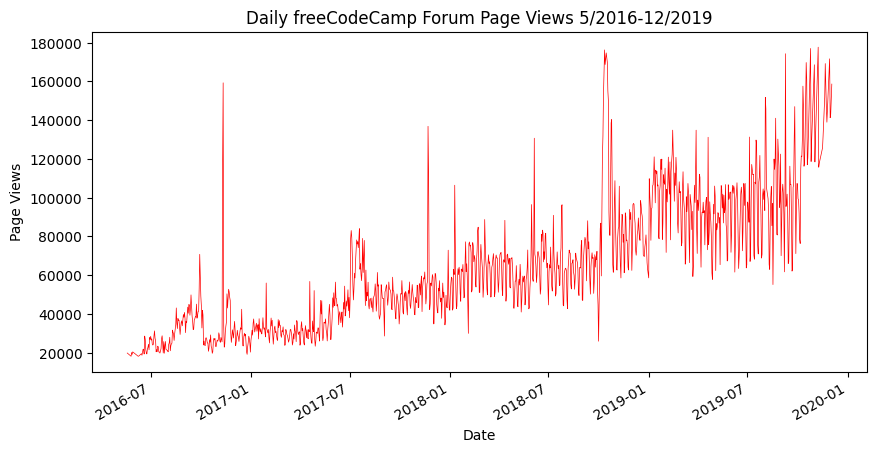

In [16]:
draw_line_plot();

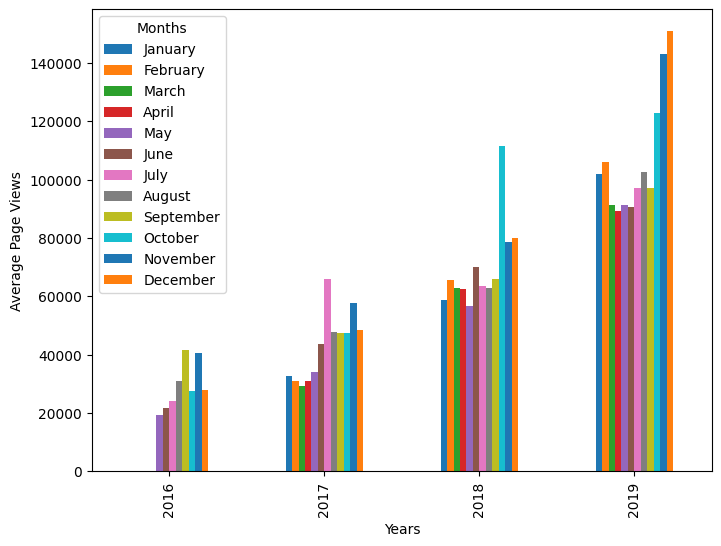

In [17]:
draw_bar_plot();

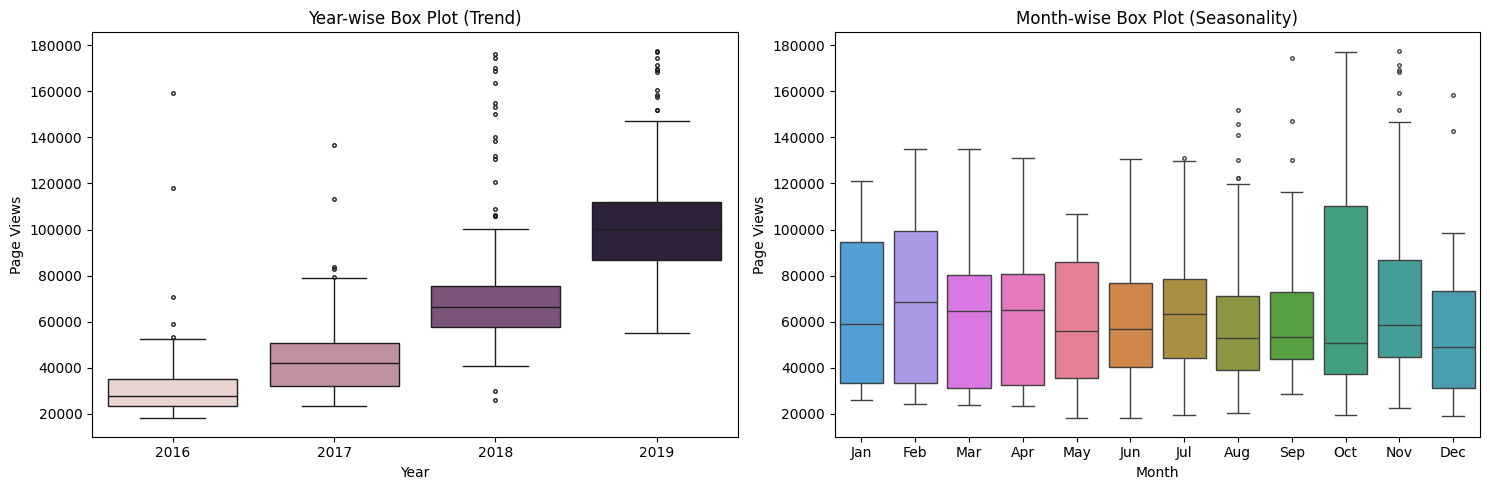

In [3]:
draw_box_plot();